In [41]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [42]:
base_dir = Path("classified_datasets/pollution")

# 1) Iterate through files and read with pandas
csv_files = sorted(base_dir.rglob("*.csv"))

dataframes = {}
datetime_candidates = {"DateTime", "timeArray", "datetime", "timestamp"}
pollutant_candidates = {"NOx", "NO", "NO2", "PM10", "O3", "CO"}

for fp in csv_files:
    try:
        df = pd.read_csv(fp, low_memory=False)

        # Keep only measurement-like tables (datetime + at least one pollutant metric).
        has_datetime = any(c in df.columns for c in datetime_candidates)
        has_pollutant = any(c in df.columns for c in pollutant_candidates)
        if has_datetime and has_pollutant:
            dataframes[str(fp)] = df
    except Exception as e:
        print(f"Failed: {fp.name} -> {e}")

combined_df = pd.concat(dataframes.values(), ignore_index=True) if dataframes else pd.DataFrame()
print("Files included:", len(dataframes))
print("Combined shape:", combined_df.shape)

Files included: 5
Combined shape: (1076416, 16)


In [43]:
df = combined_df.copy()
df.drop(columns="ID", inplace=True, errors="ignore")
df.drop_duplicates(inplace=True)
df["sensor"] = df["Sensor Location Slug"]
df["coords"] = df["Sensor Location"]

In [44]:
df["coords"] = df["coords"].apply(lambda x: x.strip("()").split(","))
df["long"] = df["coords"].apply(lambda x: round(float(x[0]), 6))
df["lat"] = df["coords"].apply(lambda x: round(float(x[1]), 6))

In [45]:
missing_percentages = df.isnull().mean() * 100
missing_percentages

DateTime                                   0.000000
Sensor Location Name                       0.000000
Sensor Location Slug                       0.000000
Sensor Location                            0.000000
NOx                                        2.082906
NO                                         2.082906
NO2                                        2.082906
CO                                        51.468120
PM10                                      80.287909
O3                                        97.917094
Ward                                      60.806282
Lower Layer Super Output Areas (LSOA)     60.806282
Output Areas (OA)                         60.806282
Middle Layer Super Output Areas (MSOA)    60.806282
Boundary                                  60.806282
sensor                                     0.000000
coords                                     0.000000
long                                       0.000000
lat                                        0.000000
dtype: float

In [46]:
df.drop(columns=["Ward", "coords", "Boundary", "Middle Layer", "Lower Layer Super Output Areas (LSOA)", "Middle Layer Super Output Areas (MSOA)", "Output Areas (OA)", "Sensor Location Name", "Sensor Location Slug", "Sensor Location"], inplace=True, errors="ignore")

In [47]:
df.drop_duplicates(inplace=True)

# Standardize timestamps to a regular interval so missing frames can be detected consistently.

In [48]:
df["timestamp"] = pd.to_datetime(
    df["DateTime"],
    errors="coerce",
    format="mixed"
)
df.drop(columns=["DateTime"], inplace=True, errors="ignore")
df

,NOx,NO,NO2,CO,PM10,O3,sensor,long,lat,timestamp
0,19.5,7.5,13.5,0.2,NaN,NaN,guildhall,51.382219,-2.359034,2014-08-07 13:00:00
1,28.0,14.0,15.5,0.225,NaN,NaN,guildhall,51.382219,-2.359034,2014-08-07 13:15:00
2,26.0,11.5,15.5,0.2,NaN,NaN,guildhall,51.382219,-2.359034,2014-08-07 13:30:00
3,15.0,6.0,10.5,0.175,NaN,NaN,guildhall,51.382219,-2.359034,2014-08-07 13:45:00
4,21.0,9.0,13.5,0.2,NaN,NaN,guildhall,51.382219,-2.359034,2014-08-07 14:00:00
...,...,...,...,...,...,...,...,...,...,...
1076407,79.8984,55.1992,24.6997,999,NaN,NaN,guildhall,51.382219,-2.359034,2018-10-17 12:15:00
1076408,1.9,0.3,1.5,999,NaN,NaN,guildhall,51.382219,-2.359034,2018-10-17 00:30:00
1076411,69.6992,43,26.6997,999,NaN,NaN,guildhall,51.382219,-2.359034,2018-10-17 12:30:00
1076412,2.7,0.5,2.2,999,NaN,NaN,guildhall,51.382219,-2.359034,2018-10-17 00:45:00


In [49]:
df.sort_values("timestamp", inplace=True)
df.reset_index(drop=True, inplace=True)

In [50]:
df.drop(index=df[df["sensor"] == "royalvicpark"].index, inplace=True, errors="ignore") # low sensor data, and mostly nan
df

,NOx,NO,NO2,CO,PM10,O3,sensor,long,lat,timestamp
0,12.207,5.4932,9.7656,NaN,14.1602,NaN,londonrdenc,51.391143,-2.354634,2014-01-08 00:00:00
1,4.5,0.0,6.5,0.2,NaN,NaN,guildhall,51.382219,-2.359034,2014-01-08 00:00:00
3,10.2499,3.725,6.5249,-0.275,15.2637,NaN,windsorbridge,51.382246,-2.381608,2014-01-08 00:00:00
4,41.8994,25.0,16.7998,NaN,NaN,NaN,londonrdaurn,51.391104,-2.354067,2014-01-08 00:00:00
6,4.0,0.0,5.5,0.2,NaN,NaN,guildhall,51.382219,-2.359034,2014-01-08 00:15:00
...,...,...,...,...,...,...,...,...,...,...
748746,29.6997,17.6997,12.0,999.0,NaN,NaN,guildhall,51.382219,-2.359034,2019-05-20 07:15:00
748747,18.0,6.7999,11.2,NaN,NaN,NaN,londonrdaurn,51.391104,-2.354067,2019-05-20 07:15:00
748748,60.6992,37.0,23.6997,999.0,NaN,NaN,guildhall,51.382219,-2.359034,2019-05-20 07:30:00
748749,35.5,14.7,20.7998,999.0,NaN,NaN,guildhall,51.382219,-2.359034,2019-05-20 07:45:00


In [51]:
df.drop(columns=["CO", "PM10", "O3"], inplace=True, errors="ignore")

In [52]:
df.drop_duplicates(subset=["timestamp","sensor"], inplace=True)

I will use global open meteo data for later and earlier data and to fill gaps of data other sources (CO2, PM10, PM2.5 ect)

# Detect regular interval gaps, excluding very large holes.

In [53]:
pollution_dic = {}
for i in df["sensor"].unique():
    pollution_dic[i] = df[df["sensor"] == i]

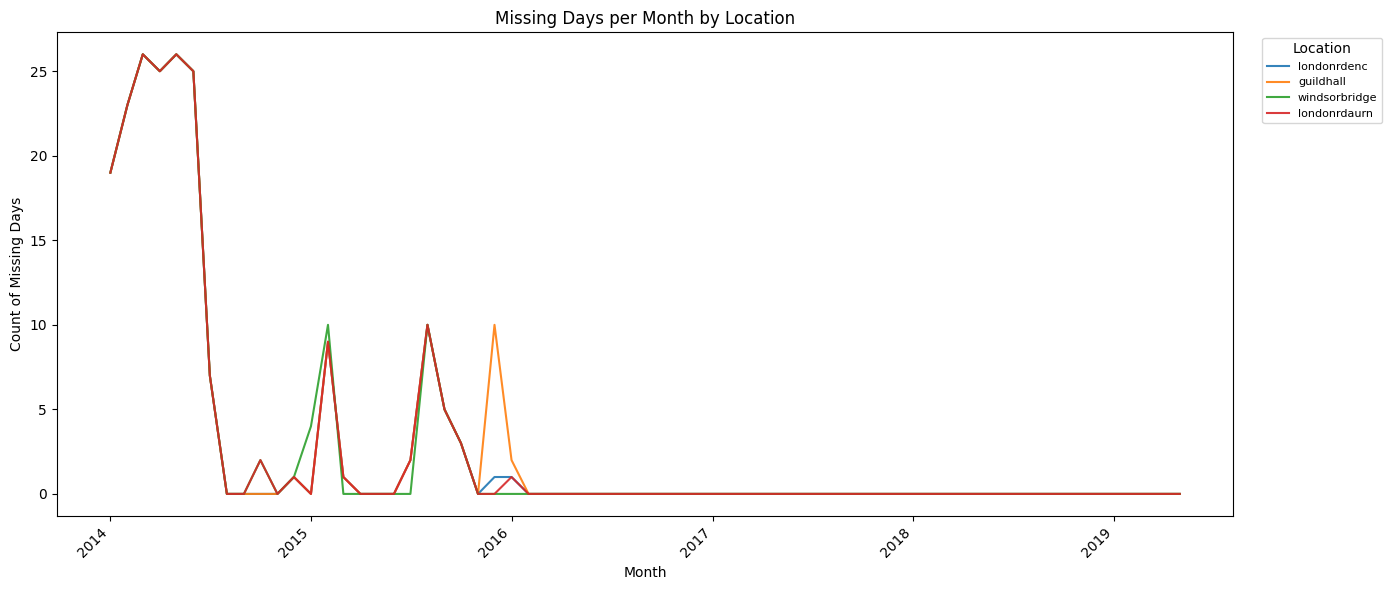

In [54]:
all_present_days = pd.to_datetime(df["timestamp"].dt.normalize().unique())
all_present_days = pd.DatetimeIndex(all_present_days).sort_values()

all_days = pd.date_range(
    start=all_present_days.min(),
    end=all_present_days.max(),
    freq="D"
)

plt.figure(figsize=(14, 6))

for loc_name, loc_df in pollution_dic.items():
    present_days = pd.to_datetime(loc_df["timestamp"].dt.normalize().unique())
    present_days = pd.DatetimeIndex(present_days).sort_values()

    day_status = pd.Series(False, index=all_days, name="present")
    day_status.loc[present_days] = True
    monthly_missing = (~day_status).resample("MS").sum()

    plt.plot(
        monthly_missing.index,
        monthly_missing.values,
        label=str(loc_name),
        linewidth=1.5,
        alpha=0.9,
    )

plt.title("Missing Days per Month by Location")
plt.ylabel("Count of Missing Days")
plt.xlabel("Month")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Location", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


In [55]:
pollution_dic = {}
for i in df["sensor"].unique():
    pollution_dic[i] = df[df["sensor"] == i]
    pollution_dic[i] = pollution_dic[i].set_index("timestamp").sort_index()
    numeric_cols = pollution_dic[i].select_dtypes(include="number").columns
    pollution_dic[i][numeric_cols] = pollution_dic[i][numeric_cols].interpolate(method="linear", limit=20)

In [56]:
for i in pollution_dic.keys():
    full_index = pd.date_range(
        start=pollution_dic[i].index.min(),
        end=pollution_dic[i].index.max(),
        freq='1h'
    )
    pollution_dic[i] = pollution_dic[i].reindex(full_index)
    
    
    is_nan = pollution_dic[i]['NOx'].isna()
    
    nan_groups = (is_nan != is_nan.shift()).cumsum()
    group_sizes = pollution_dic[i].groupby(nan_groups)['NOx'].transform('size')
    
    large_missing_chunk = is_nan & (group_sizes > 5)
    pollution_dic[i] = pollution_dic[i][~large_missing_chunk]

In [57]:
pollution_dic

{'londonrdenc':                          NOx       NO      NO2       sensor       long  \
 2014-01-08 00:00:00   12.207   5.4932   9.7656  londonrdenc  51.391143   
 2014-01-08 01:00:00   8.5449   4.2725   6.7139  londonrdenc  51.391143   
 2014-01-08 02:00:00  10.9863   4.8828   8.5449  londonrdenc  51.391143   
 2014-01-08 03:00:00  14.0381   7.3242   9.7656  londonrdenc  51.391143   
 2014-01-08 04:00:00  16.4795   9.1553   10.376  londonrdenc  51.391143   
 ...                      ...      ...      ...          ...        ...   
 2019-05-20 03:00:00   9.4249      2.4      7.0  londonrdenc  51.391143   
 2019-05-20 04:00:00  15.9498    4.775  11.1249  londonrdenc  51.391143   
 2019-05-20 05:00:00  32.6497    16.15  16.4998  londonrdenc  51.391143   
 2019-05-20 06:00:00  30.2246  17.3249  12.8248  londonrdenc  51.391143   
 2019-05-20 07:00:00  21.6246  12.1249   9.4499  londonrdenc  51.391143   
 
                           lat  
 2014-01-08 00:00:00 -2.354634  
 2014-01-08 01:00

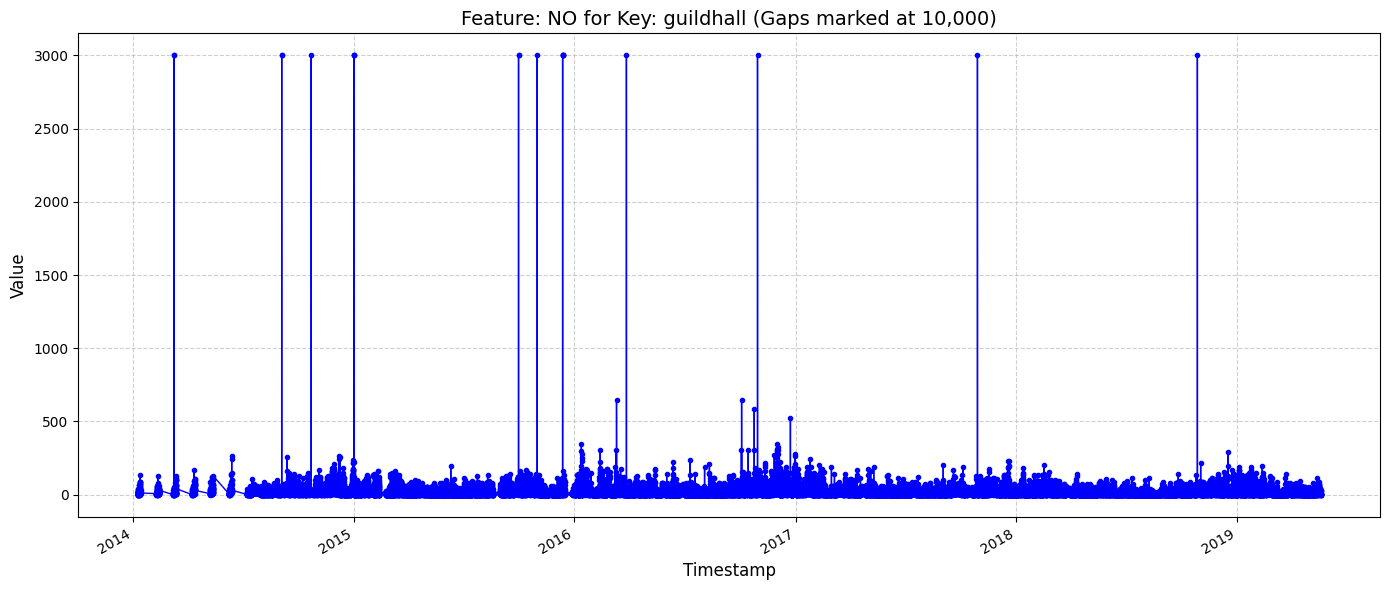

In [58]:
sample_key = list(pollution_dic.keys())[1]
df_to_plot = pollution_dic[sample_key]
df_to_plot["NO"] = df_to_plot["NO"].astype(float)
filled_series = df_to_plot['NO'].fillna(3000)

filled_series.plot(figsize=(14, 6), color='blue', marker='.', linestyle='-', linewidth=1)

plt.title(f"Feature: {'NO'} for Key: {sample_key} (Gaps marked at 10,000)", fontsize=14)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

In [59]:
for key, df in pollution_dic.items():
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [60]:
for key, df in pollution_dic.items():
    df.interpolate(method="linear", limit=6, inplace=True)
    df["sensor"] = key
    df.reset_index(inplace=True)
    df.rename(columns={"index":"timestamp"}, inplace=True)

In [61]:
# take only 2014/07 data onwards
for key in pollution_dic.keys():
    pollution_dic[key] = pollution_dic[key][pollution_dic[key]["timestamp"] >= "2014-07-01"]

In [62]:
pollution_dic

{'londonrdenc':                 timestamp      NOx       NO      NO2       sensor       long  \
 713   2014-07-08 00:00:00  10.3760   5.4932   8.5449  londonrdenc  51.391143   
 714   2014-07-08 01:00:00  12.8174   4.8828  10.9863  londonrdenc  51.391143   
 715   2014-07-08 02:00:00  12.2070   4.2725  10.9863  londonrdenc  51.391143   
 716   2014-07-08 03:00:00  18.9209   9.1553  12.8174  londonrdenc  51.391143   
 717   2014-07-08 04:00:00  26.2451  14.0381  14.6484  londonrdenc  51.391143   
 ...                   ...      ...      ...      ...          ...        ...   
 42203 2019-05-20 03:00:00   9.4249   2.4000   7.0000  londonrdenc  51.391143   
 42204 2019-05-20 04:00:00  15.9498   4.7750  11.1249  londonrdenc  51.391143   
 42205 2019-05-20 05:00:00  32.6497  16.1500  16.4998  londonrdenc  51.391143   
 42206 2019-05-20 06:00:00  30.2246  17.3249  12.8248  londonrdenc  51.391143   
 42207 2019-05-20 07:00:00  21.6246  12.1249   9.4499  londonrdenc  51.391143   
 
           

In [63]:
a = 0
for key, df in pollution_dic.items():
    df["sensor_id"] = a
    a += 1

In [64]:
import pickle
with open("pollution_dic.pkl", "wb") as f:
    pickle.dump(pollution_dic, f)

In [65]:
pollution_dic

{'londonrdenc':                 timestamp      NOx       NO      NO2       sensor       long  \
 713   2014-07-08 00:00:00  10.3760   5.4932   8.5449  londonrdenc  51.391143   
 714   2014-07-08 01:00:00  12.8174   4.8828  10.9863  londonrdenc  51.391143   
 715   2014-07-08 02:00:00  12.2070   4.2725  10.9863  londonrdenc  51.391143   
 716   2014-07-08 03:00:00  18.9209   9.1553  12.8174  londonrdenc  51.391143   
 717   2014-07-08 04:00:00  26.2451  14.0381  14.6484  londonrdenc  51.391143   
 ...                   ...      ...      ...      ...          ...        ...   
 42203 2019-05-20 03:00:00   9.4249   2.4000   7.0000  londonrdenc  51.391143   
 42204 2019-05-20 04:00:00  15.9498   4.7750  11.1249  londonrdenc  51.391143   
 42205 2019-05-20 05:00:00  32.6497  16.1500  16.4998  londonrdenc  51.391143   
 42206 2019-05-20 06:00:00  30.2246  17.3249  12.8248  londonrdenc  51.391143   
 42207 2019-05-20 07:00:00  21.6246  12.1249   9.4499  londonrdenc  51.391143   
 
           